## 1. Setup

In [ ]:
import cv2
import numpy as np
import json
import glob
import os
from pathlib import Path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Config 
_env_cfg = os.environ.get('SARBORN_CONFIG_PATH')
if _env_cfg:
    CONFIG_PATH = Path(_env_cfg)
else:
    _p = Path.cwd().resolve()
    CONFIG_PATH = None
    for _cand in [_p, *_p.parents]:
        _cfg = _cand / 'config.json'
        if _cfg.exists():
            CONFIG_PATH = _cfg
            break
    if CONFIG_PATH is None:
        CONFIG_PATH = Path.cwd() / 'config.json'

with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    cfg = json.load(f)

# Paths
IMAGE_DIR = cfg['data']['images_dir']
LABEL_DIR = cfg['data']['labels_dir']
STEP1_BASELINE_RESULT_PNG = cfg['output']['step1_baseline_result_png']

# Fixed colors
FIXED_COLORS = {
    # Brick (pink)
    'brick': [205, 168, 159],
    # Wood (yellow)
    'wood':  [136, 130,  60],
}

CLASS_COLORS = {0: (200,195,185), 1: (241,196,15), 2: (231,76,60)}

print(f'Fixed brick color: {FIXED_COLORS["brick"]}')
print(f'Fixed wood color:  {FIXED_COLORS["wood"]}')

Fixed brick color: [205, 168, 159]
Fixed wood color:  [136, 130, 60]


## 2. Load Data

In [2]:
def load_gt(json_path, h, w):
    lmap = {'木':1, '砖':2, 'wood':1, 'brick':2}
    img2 = Image.new('L', (w,h), 0)
    draw = ImageDraw.Draw(img2)
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    for s in data.get('shapes', []):
        if s['label'] in lmap:
            draw.polygon([tuple(p) for p in s['points']], fill=lmap[s['label']])
    return np.array(img2)

def mask_to_rgb(mask):
    rgb = np.zeros((*mask.shape,3), dtype=np.uint8)
    for c,col in CLASS_COLORS.items(): rgb[mask==c] = col
    return rgb

def compute_iou(pred, gt, nc=3):
    names = ['BG','Wood','Brick']
    r = {}
    for c in range(nc):
        tp = ((pred==c)&(gt==c)).sum()
        fp = ((pred==c)&(gt!=c)).sum()
        fn = ((pred!=c)&(gt==c)).sum()
        r[names[c]] = float(tp/(tp+fp+fn+1e-8))
    r['mIoU'] = float(np.mean(list(r.values())))
    return r

# Load test images
test_data = []
for jf in glob.glob(os.path.join(LABEL_DIR, '*.json')):
    name = os.path.splitext(os.path.basename(jf))[0]
    ip = os.path.join(IMAGE_DIR, name+'.jpg')
    if not os.path.exists(ip): continue
    img = np.array(Image.open(ip).convert('RGB'))
    gt  = load_gt(jf, *img.shape[:2])
    test_data.append({'name': name, 'image': img, 'gt': gt})
    print(f'Loaded: {name}  {img.shape}  classes={np.unique(gt)}')
print(f'Total: {len(test_data)} test maps')

Loaded: sanborn00001_001_1  (1913, 1613, 3)  classes=[0 1 2]
Loaded: sanborn00002_001_4  (1913, 1613, 3)  classes=[0 1 2]
Loaded: sanborn00006_003_2  (1913, 1613, 3)  classes=[0 2]
Loaded: sanborn00074_007_51  (1920, 1640, 3)  classes=[0 1 2]
Total: 4 test maps


## 3. Fixed Color Matching

In [3]:
def color_match_fixed(img_rgb, brick_color, wood_color, threshold=35, min_area=300):
    """Simple NN color match with a distance threshold."""
    pixels = img_rgb.astype(np.float32).reshape(-1, 3)
    H, W   = img_rgb.shape[:2]
    db = np.linalg.norm(pixels - np.array(brick_color, dtype=np.float32), axis=1)
    dw = np.linalg.norm(pixels - np.array(wood_color,  dtype=np.float32), axis=1)
    pred = np.zeros(H*W, dtype=np.uint8)
    mn   = np.minimum(db, dw)
    vld  = mn < threshold
    pred[vld & (db<dw)] = 2  # brick
    pred[vld & (dw<db)] = 1  # wood
    pred = pred.reshape(H, W)

    # Drop small components
    for c in [1,2]:
        m = (pred==c).astype(np.uint8)
        n,lbl,st,_ = cv2.connectedComponentsWithStats(m, connectivity=8)
        for l in range(1,n):
            if st[l,cv2.CC_STAT_AREA] < min_area: pred[lbl==l]=0
    return pred

# Run on all test maps
print(f'{"Map":<25} {"BG":>8} {"Wood":>8} {"Brick":>8} {"mIoU":>8}')
print('-'*55)
all_ious = []
for d in test_data:
    pred = color_match_fixed(d['image'], FIXED_COLORS['brick'], FIXED_COLORS['wood'])
    r    = compute_iou(pred, d['gt'])
    all_ious.append(r)
    print(f'{d["name"]:<25} {r["BG"]:>8.3f} {r["Wood"]:>8.3f} {r["Brick"]:>8.3f} {r["mIoU"]:>8.3f}')
    d['pred_fixed'] = pred

print('-'*55)
avg = {k: np.mean([r[k] for r in all_ious]) for k in all_ious[0]}
print(f'{"Average":<25} {avg["BG"]:>8.3f} {avg["Wood"]:>8.3f} {avg["Brick"]:>8.3f} {avg["mIoU"]:>8.3f}')

Map                             BG     Wood    Brick     mIoU
-------------------------------------------------------
sanborn00001_001_1           0.885    0.000    0.649    0.511
sanborn00002_001_4           0.901    0.000    0.312    0.405
sanborn00006_003_2           0.931    0.000    0.327    0.420
sanborn00074_007_51          0.779    0.278    0.000    0.352
-------------------------------------------------------
Average                      0.874    0.069    0.322    0.422


## 4. Visualization

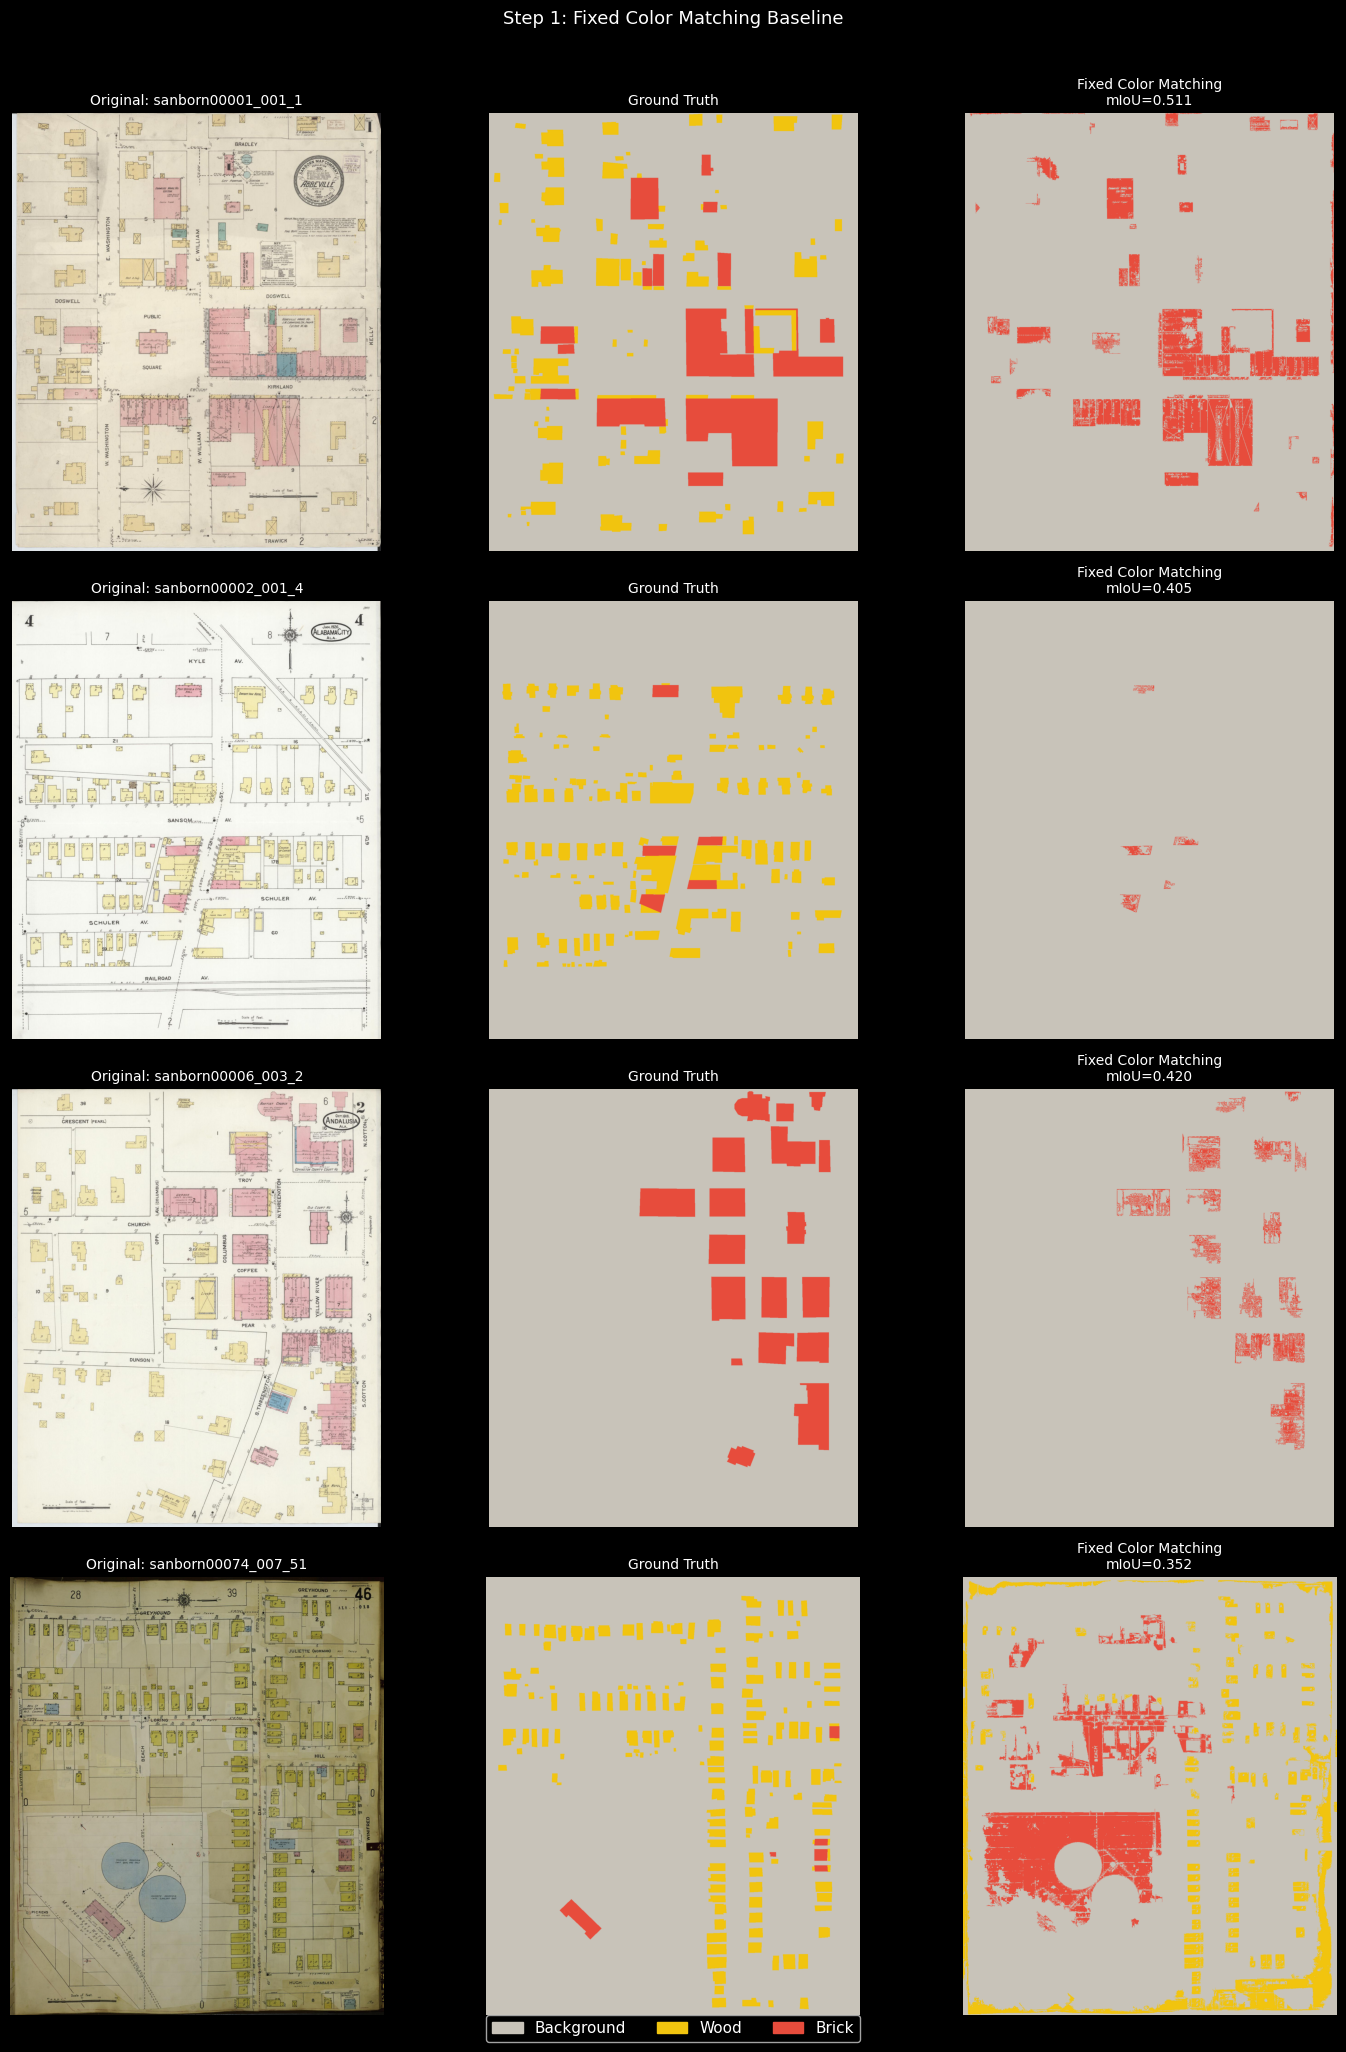

In [4]:
n = min(4, len(test_data))
fig, axes = plt.subplots(n, 3, figsize=(15, 5*n))
if n==1: axes = axes[np.newaxis,:]

for i, d in enumerate(test_data[:n]):
    axes[i][0].imshow(d['image'])
    axes[i][0].set_title(f'Original: {d["name"]}', fontsize=10); axes[i][0].axis('off')
    axes[i][1].imshow(mask_to_rgb(d['gt']))
    axes[i][1].set_title('Ground Truth', fontsize=10); axes[i][1].axis('off')
    r = compute_iou(d['pred_fixed'], d['gt'])
    axes[i][2].imshow(mask_to_rgb(d['pred_fixed']))
    axes[i][2].set_title(f'Fixed Color Matching\nmIoU={r["mIoU"]:.3f}', fontsize=10)
    axes[i][2].axis('off')

legend = [mpatches.Patch(color=[c/255 for c in CLASS_COLORS[i]], label=l)
          for i,l in zip([0,1,2],['Background','Wood','Brick'])]
fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=11, bbox_to_anchor=(0.5,-0.01))
plt.suptitle('Step 1: Fixed Color Matching Baseline', fontsize=13, y=1.01)
plt.tight_layout()

# EN: Save figure to configured output path
os.makedirs(os.path.dirname(STEP1_BASELINE_RESULT_PNG), exist_ok=True)
plt.savefig(STEP1_BASELINE_RESULT_PNG, dpi=120, bbox_inches='tight')
plt.show()